# Modelado y evaluación - consumo doméstico

**Reto técnico NTT Data — High Garden Coffee**

Cubre los requisitos *"solución a las problemáticas de negocio"* e *"implementación
y evaluación"*.

La pregunta que responde este notebook no es "¿qué modelo uso?", sino **"¿vale la
pena modelar?"**. La respuesta resultó ser *depende del país*, y descubrir de qué
depende fue el hallazgo principal del trabajo.

El backtesting se ejecuta desde `src/coffee/evaluate.py` (tarda ~8 min) y deja los
resultados cacheados. Aquí solo se leen y se interpretan.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from coffee.data import load_clean
from coffee.evaluate import (
    attach_quality, by_horizon, summarize, summarize_by_tier, vs_naive,
)

pd.set_option("display.width", 200)
FIGS = Path.cwd().parent / "reports" / "figures"

plt.rcParams.update({
    "figure.figsize": (11, 5), "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.25, "font.size": 11,
})

panel, _ = load_clean()
res = attach_quality(
    pd.read_parquet(Path.cwd().parent / "data" / "processed" / "backtest_consumo.parquet"),
    panel,
)
print(f"{len(res):,} evaluaciones | {res.country.nunique()} países | "
      f"{res.cut_year.nunique()} cortes | {res.model.nunique()} modelos")

3,156 evaluaciones | 42 países | 13 cortes | 6 modelos


## 1. El protocolo de evaluación

Con series de tiempo **no se puede usar `train_test_split`**: partir al azar entrena
con el futuro para predecir el pasado, y las métricas salen infladas por información
que en producción no existiría.

Se usa **origen móvil**: se fija un año de corte, se entrena solo con lo anterior y
se predicen los tres años siguientes. El corte avanza y se repite.

```
corte 2004:  entrena 1990-2004  ->  predice 2005, 2006, 2007
corte 2005:  entrena 1990-2005  ->  predice 2006, 2007, 2008
...
corte 2016:  entrena 1990-2016  ->  predice 2017, 2018, 2019
```

Así cada evaluación respeta la flecha del tiempo, y en vez de un número se obtiene
una distribución de errores sobre 13 orígenes distintos.

**Métrica principal: MASE**, no MAPE. El consumo va de 1.2e5 (Burundi) a 1.3e9
(Brasil); el MAPE castiga desproporcionadamente los valores pequeños y no permite
promediar entre países. MASE es adimensional:

- `MASE < 1` → mejor que repetir el último valor
- `MASE > 1` → el modelo estorba

## 2. El resultado agregado, que resultó ser una trampa

In [2]:
summarize(res)

,mase_mediana,mase_media,mape_mediana,smape_mediana,pct_gana_a_naive,n
model,,,,,,
arima,0.444,1.713,2.291,2.291,18.441,526
naive,0.461,1.824,2.730,2.730,0.000,526
drift,0.834,1.911,4.094,4.068,34.411,526
ets,0.982,2.865,5.168,5.224,31.179,526
global_lgbm,1.401,2.757,7.035,6.984,23.384,526
mean,4.779,6.947,25.295,26.777,7.414,526


Leído de frente, esto dice: **no modelen**. El naive queda segundo, y el
LightGBM global —el enfoque de machine learning— queda por debajo de repetir el
último valor.

Y ARIMA, que aparece primero, apenas le gana al naive en 18% de los casos. Eso no
cuadraba, así que vale la pena mirar la comparación pareada.

In [3]:
c = vs_naive(res, "arima")
print(f"ARIMA gana : {c['gana']:5.1f}%")
print(f"EMPATE     : {c['empata']:5.1f}%   <- ARIMA(0,1,0) ES la caminata aleatoria")
print(f"NAIVE gana : {c['pierde']:5.1f}%")
print(f"\n(n = {c['n']} pares corte-país)")

ARIMA gana :  18.9%
EMPATE     :  65.5%   <- ARIMA(0,1,0) ES la caminata aleatoria
NAIVE gana :  15.6%

(n = 513 pares corte-país)


En dos tercios de los casos, ARIMA **elige por criterio de información el orden
(0,1,0)** — una caminata aleatoria, cuyo pronóstico es exactamente el del naive.
ARIMA no le gana al naive: *se convierte* en él.

La lectura natural sería "estas series no tienen estructura explotable". Esa
lectura es **incorrecta**, y la siguiente sección explica por qué.

## 3. Por qué el agregado engaña: la mitad del panel no son mediciones

El indicio fue Kenia, cuyo MASE (18.15) era cuatro veces peor que el del segundo
peor país. Al mirar la serie:

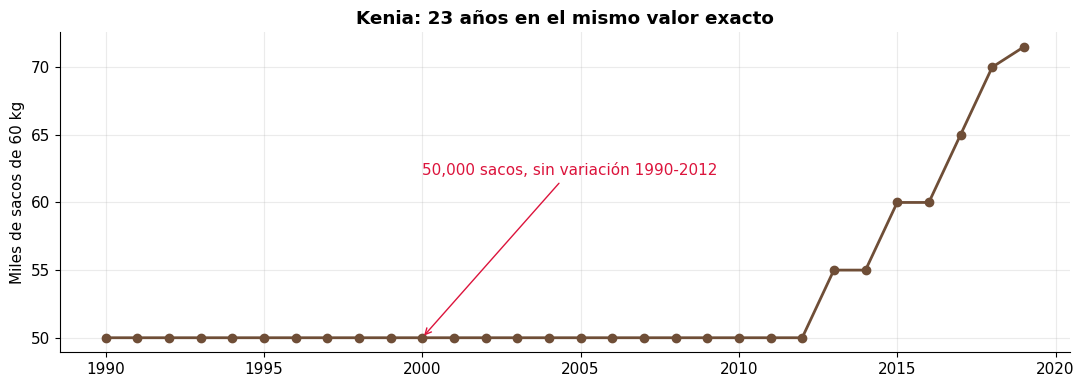

year
1990    50.0
1991    50.0
1992    50.0
1993    50.0
1994    50.0
1995    50.0
1996    50.0
1997    50.0
1998    50.0
1999    50.0
2000    50.0
2001    50.0
2002    50.0
2003    50.0
2004    50.0
2005    50.0
2006    50.0
2007    50.0
2008    50.0
2009    50.0
2010    50.0
2011    50.0
2012    50.0
2013    55.0
2014    55.0
2015    60.0
2016    60.0
2017    65.0
2018    70.0
2019    71.5


In [4]:
kenya = panel[panel.country == "Kenya"].sort_values("year")
serie = kenya.set_index("year").consumption_bags_60kg / 1000

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(serie.index, serie.values, marker="o", lw=2, color="#6F4E37")
ax.set_title("Kenia: 23 años en el mismo valor exacto", weight="bold")
ax.set_ylabel("Miles de sacos de 60 kg")
ax.annotate("50,000 sacos, sin variación 1990-2012",
            xy=(2000, 50), xytext=(2000, 62),
            arrowprops=dict(arrowstyle="->", color="crimson"), color="crimson")
fig.tight_layout()
fig.savefig(FIGS / "06_kenia.png", dpi=150)
plt.show()

print(serie.round(1).to_string())

El MASE de Kenia explota porque su denominador es el cambio medio año a año del
entrenamiento, y ese cambio es **cero**. No es que los modelos fallen: es que la
métrica se vuelve inestable cuando la serie es constante.

Kenia tiene 6 valores distintos, así que pasó el filtro `LOW_VARIANCE_MAX_DISTINCT = 3`
de la limpieza. Eso sugirió que el criterio era demasiado laxo. Midiendo en cambio el
**porcentaje de años sin ningún cambio**:

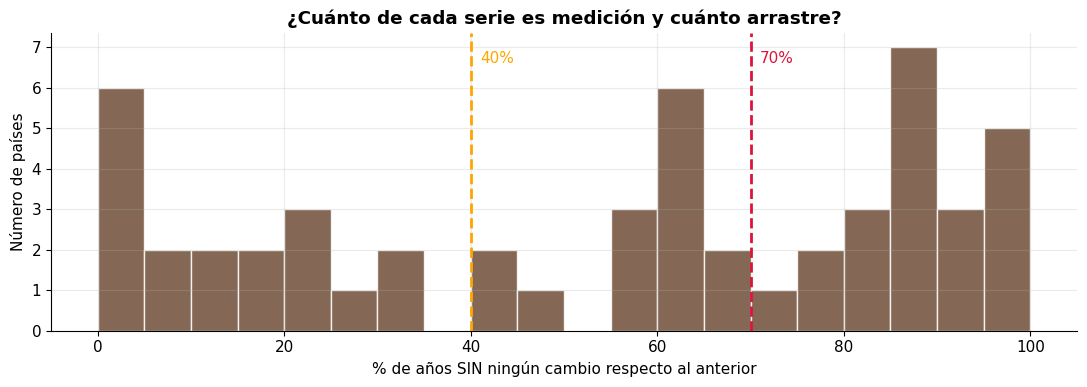

Mediana del panel: 62.1% de años planos

Los 8 más extremos:
country
Timor-Leste                     100.0
Paraguay                         96.6
Liberia                          96.6
Malawi                           96.6
Democratic Republic of Congo     96.6
Nigeria                          93.1
Congo                            93.1
Côte d'Ivoire                    93.1


In [5]:
flat = panel.groupby("country").flat_years_pct.first().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(flat.values, bins=20, color="#6F4E37", alpha=0.85, edgecolor="white")
for x, c, t in [(40, "orange", "40%"), (70, "crimson", "70%")]:
    ax.axvline(x, ls="--", color=c, lw=2)
    ax.text(x + 1, ax.get_ylim()[1] * 0.9, t, color=c)
ax.set_title("¿Cuánto de cada serie es medición y cuánto arrastre?", weight="bold")
ax.set_xlabel("% de años SIN ningún cambio respecto al anterior")
ax.set_ylabel("Número de países")
fig.tight_layout()
fig.savefig(FIGS / "07_calidad_dato.png", dpi=150)
plt.show()

print(f"Mediana del panel: {flat.median():.1f}% de años planos\n")
print("Los 8 más extremos:")
print(flat.head(8).round(1).to_string())

**Más de la mitad de las variaciones año a año del panel son exactamente cero.**

Esto no es ruido ni azar: la ICO arrastra el último valor conocido cuando un país no
reporta. Zimbabwe, Guinea, Perú y Haití tienen **89.7%** de años sin cambio alguno.

Esto reinterpreta el resultado agregado. El naive no ganaba por ser bueno: ganaba
porque en buena parte del panel la respuesta correcta *es*, literalmente, "lo mismo
del año pasado".

Se etiqueta cada país en tres niveles (`data_quality` en `src/coffee/data.py`), como
atributo medido y **no** como filtro que elimina países:

In [6]:
niveles = panel.groupby("data_quality").country.nunique()
print(niveles.reindex(["medido", "mixto", "arrastrado"]).to_string())

data_quality
medido        18
mixto         14
arrastrado    21


## 4. El mismo backtesting, segmentado: la conclusión se invierte

In [7]:
for tier, tabla in summarize_by_tier(res).items():
    print(f"=== {tier.upper()}  ({int(tabla.n_paises.iloc[0])} países) ===")
    print(tabla.drop(columns="n_paises").to_string())
    print()

=== MEDIDO  (18 países) ===
             mase_mediana  mape_mediana  gana_a_naive_%  empates_%
model                                                             
drift                0.76          3.65           70.45       2.65
arima                0.84          3.29           75.93      52.21
ets                  0.98          4.42           57.52       0.00
naive                1.50          5.23             NaN        NaN
global_lgbm          1.89          7.13           38.50       0.00
mean                10.07         33.62            2.21       0.00

=== MIXTO  (12 países) ===
             mase_mediana  mape_mediana  gana_a_naive_%  empates_%
model                                                             
naive                0.32          1.12             NaN        NaN
arima                0.42          3.52           31.91      66.43
ets                  0.81          5.74           20.00       0.00
drift                0.83          3.48           15.32      11.43
global

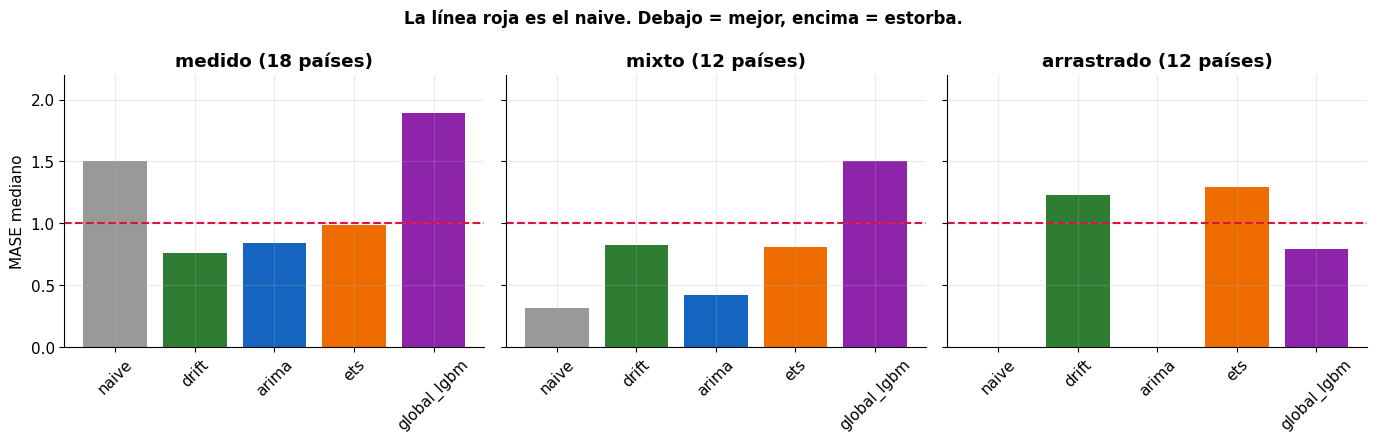

In [8]:
tiers = ["medido", "mixto", "arrastrado"]
modelos = ["naive", "drift", "arima", "ets", "global_lgbm"]
colores = {"naive": "#999999", "drift": "#2E7D32", "arima": "#1565C0",
           "ets": "#EF6C00", "global_lgbm": "#8E24AA"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
for ax, tier in zip(axes, tiers):
    sub = res[res.data_quality == tier]
    vals = [sub[sub.model == m].mase.median() for m in modelos]
    ax.bar(modelos, vals, color=[colores[m] for m in modelos])
    ax.axhline(1, ls="--", color="crimson", lw=1.5)
    ax.set_title(f"{tier} ({sub.country.nunique()} países)", weight="bold")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("MASE mediano")
axes[0].set_ylim(0, 2.2)
fig.suptitle("La línea roja es el naive. Debajo = mejor, encima = estorba.",
             fontsize=12, weight="bold")
fig.tight_layout()
fig.savefig(FIGS / "08_mase_por_nivel.png", dpi=150)
plt.show()

### Esto es una paradoja de Simpson

| | Agregado | Solo países medidos |
|---|---|---|
| naive | 0.46 (2º) | **1.50 (4º)** |
| drift | 0.83 (3º) | **0.76 (1º)** |

En los 18 países con medición real, **drift le gana al naive con holgura** (0.76
contra 1.50) y lo supera en el 70% de los casos no empatados. En los países
arrastrados, el naive acierta con error exactamente **0.00%**, porque la serie es
constante por construcción.

Esos ceros arrastraban la mediana global y escondían el resultado real. **La
conclusión agregada era la opuesta a la conclusión en cada subgrupo.**

## 5. Lo que sí resistió: el machine learning pierde igual

El `global_lgbm` queda en **1.89** dentro del nivel *medido*, contra 0.76 de drift.
Pierde incluso contra los datos limpios.

Y no es por implementación pobre: es un modelo global entrenado sobre los 43 países
a la vez (~1,290 observaciones en vez de 30), sobre tasas de crecimiento
logarítmicas para que Brasil y Burundi sean comparables. Es la arquitectura que ganó
la competencia M5.

**Esta es la justificación empírica de descartar el deep learning.** Se probó el
enfoque de ML más razonable disponible, con el protocolo correcto, y perdió
contra una recta ajustada por dos puntos.

Con 30 observaciones anuales por serie, un modelo con miles de parámetros no
aprende: memoriza.

## 6. Cómo se degrada cada modelo con el horizonte

Solo países con medición real (MAPE mediano %):
             ape_h1  ape_h2  ape_h3
model                              
arima          1.68    3.48    5.07
drift          1.98    3.35    4.97
ets            2.42    4.15    6.54
global_lgbm    3.81    7.50    9.91
mean          31.77   33.71   34.94
naive          2.66    5.38    7.30


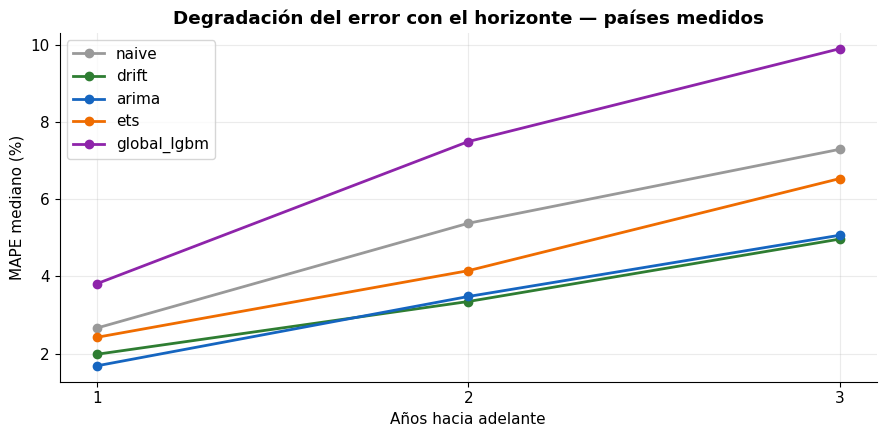

In [9]:
deg = by_horizon(res[res.data_quality == "medido"])
print("Solo países con medición real (MAPE mediano %):")
print(deg.to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
for m in modelos:
    if m in deg.index:
        ax.plot([1, 2, 3], deg.loc[m].values, marker="o", lw=2,
                label=m, color=colores[m])
ax.set_xticks([1, 2, 3])
ax.set_xlabel("Años hacia adelante")
ax.set_ylabel("MAPE mediano (%)")
ax.set_title("Degradación del error con el horizonte — países medidos", weight="bold")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "09_horizonte.png", dpi=150)
plt.show()

## 7. Conclusiones

**Sobre el dato**

1. Más del 50% de las variaciones año a año del panel son exactamente cero: son
   arrastres administrativos de la ICO, no mediciones. Solo **18 de 55 países**
   tienen series con medición razonablemente continua.
2. Kenia, el peor caso, estuvo 23 años reportando el mismo valor exacto.

**Sobre el modelado**

3. Evaluar sobre el panel agregado produce la conclusión **equivocada** de que no
   vale la pena modelar. Es un artefacto de composición.
4. En los países con medición real, **drift es el mejor modelo** (MASE 0.76) y supera
   al naive en el 70% de los casos. ARIMA queda muy cerca (0.84).
5. En los países arrastrados, **el naive es óptimo** y no es una concesión: la serie
   es constante, así que acierta exactamente.
6. El machine learning (LightGBM global) pierde en todos los segmentos. Con 30
   observaciones por serie, la complejidad no se paga.

**Recomendación operativa**

| Segmento | Modelo | Justificación |
|---|---|---|
| Medido (18 países) | **drift** | MASE 0.76, gana al naive el 70% de las veces |
| Mixto (14) | naive o ARIMA | prácticamente equivalentes |
| Arrastrado (21) | **naive** | óptimo por construcción; no reportar como pronóstico |